# 05. Model Evaluation

---

## Objective

This notebook performs a comprehensive evaluation of all trained machine learning models developed in **04_model_training.ipynb**.

The evaluation goes beyond traditional accuracy metrics by assessing classification performance, probability estimation, threshold sensitivity, model calibration, and business impact. The goal is to identify the most reliable and deployment-ready model for customer churn prediction.

---

## Key Tasks

- Load trained models and evaluation artifacts
- Evaluate classification performance on the test dataset
- Compare models using multiple evaluation metrics
- Analyze confusion matrices and classification reports
- Compare ROC and Precision–Recall curves
- Perform threshold optimization analysis
- Assess model calibration and generalization
- Rank models using multiple evaluation criteria
- Recommend the best production-ready model
- Export evaluation reports and visualizations

---

## Expected Outputs

By the end of this notebook, the following artifacts will be generated:

- Model Performance Summary
- Confusion Matrices
- Classification Reports
- ROC Curve Comparison
- Precision–Recall Curve Comparison
- Threshold Analysis Report
- Calibration Analysis
- Model Ranking Report
- Production Recommendation
- Evaluation Visualizations

In [1]:
# ==========================================================
# Standard Library Imports
# ==========================================================
import warnings
from pathlib import Path

# ==========================================================
# Data Manipulation
# ==========================================================
import numpy as np
import pandas as pd
import sys

# ==========================================================
# Data Visualization
# ==========================================================
import matplotlib.pyplot as plt
import seaborn as sns

# ==========================================================
# Model Serialization
# ==========================================================
import joblib

# ==========================================================
# Machine Learning Evaluation Metrics
# ==========================================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    precision_recall_curve,
    auc,
    ConfusionMatrixDisplay,
    balanced_accuracy_score,
    matthews_corrcoef,
    cohen_kappa_score,
    log_loss,
    brier_score_loss
)

from sklearn.calibration import calibration_curve

# ==========================================================
# Display Settings
# ==========================================================
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

plt.style.use("default")
sns.set_theme(style="whitegrid")

print("✅ Libraries imported successfully.")

PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

✅ Libraries imported successfully.


In [2]:
# ==========================================================
# Project Configuration
# ==========================================================
from src.config.paths import (
    MODELS_DIR,
    ARTIFACTS_DIR,
    REPORTS_DIR,
    REPORTS_MODEL_DIR,
    REPORTS_FIGURES_DIR,
    PROCESSED_DATA_DIR
)

from src.config.settings import (
    RANDOM_STATE,
    TARGET_COLUMN
)

# ==========================================================
# Project Utilities
# ==========================================================
from src.utils.helpers import (
    print_section,
    create_directory
)

print("✅ Project modules imported successfully.")

✅ Project modules imported successfully.


In [3]:
# ==========================================================
# Notebook Configuration
# ==========================================================
print_section("MODEL EVALUATION CONFIGURATION")

MODEL_NAMES = [
    "Logistic Regression",
    "Decision Tree",
    "Random Forest",
    "XGBoost"
]

RANDOM_SEED = RANDOM_STATE

print(f"Random State      : {RANDOM_SEED}")
print(f"Target Column     : {TARGET_COLUMN}")
print(f"Models Evaluated  : {len(MODEL_NAMES)}")

print("\nModels:")
for i, model in enumerate(MODEL_NAMES, start=1):
    print(f"{i}. {model}")

MODEL EVALUATION CONFIGURATION
Random State      : 42
Target Column     : Churn
Models Evaluated  : 4

Models:
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. XGBoost


In [4]:
# ==========================================================
# Create Output Directories
# ==========================================================
FIGURES_DIR = REPORTS_FIGURES_DIR
EVALUATION_DIR = REPORTS_MODEL_DIR

create_directory(FIGURES_DIR)
create_directory(EVALUATION_DIR)

print("✅ Output directories verified.")
print(f"Figures Directory   : {FIGURES_DIR}")
print(f"Model Reports Directory: {EVALUATION_DIR}")

✅ Output directories verified.
Figures Directory   : D:\customer-churn-intelligence-platform\reports\figures
Model Reports Directory: D:\customer-churn-intelligence-platform\reports\model


In [5]:
# ==========================================================
# Load Evaluation Dataset
# ==========================================================
print_section("LOADING EVALUATION DATASET")

X_test = pd.read_csv(PROCESSED_DATA_DIR / "X_test.csv")
y_test = pd.read_csv(PROCESSED_DATA_DIR / "y_test.csv").squeeze()

print(f"✓ X_test Shape : {X_test.shape}")
print(f"✓ y_test Shape : {y_test.shape}")

LOADING EVALUATION DATASET
✓ X_test Shape : (1405, 50)
✓ y_test Shape : (1405,)


In [6]:
# ==========================================================
# Load Trained Models
# ==========================================================
print_section("LOADING TRAINED MODELS")

MODEL_FILES = {
    "Logistic Regression": MODELS_DIR / "logistic_regression.pkl",
    "Decision Tree": MODELS_DIR / "decision_tree.pkl",
    "Random Forest": MODELS_DIR / "random_forest.pkl",
    "XGBoost": MODELS_DIR / "xgboost.pkl"
}

trained_models = {}

for model_name, model_path in MODEL_FILES.items():

    model = joblib.load(model_path)

    trained_models[model_name] = model

    print(f"✓ Loaded {model_name}")

print(f"\nTotal Models Loaded : {len(trained_models)}")

LOADING TRAINED MODELS
✓ Loaded Logistic Regression
✓ Loaded Decision Tree
✓ Loaded Random Forest
✓ Loaded XGBoost

Total Models Loaded : 4


In [7]:
# ==========================================================
# Load Preprocessing Pipeline
# ==========================================================
print_section("LOADING PREPROCESSOR")

preprocessor = joblib.load(ARTIFACTS_DIR / "preprocessor.pkl")

print("✓ Preprocessing pipeline loaded successfully.")

LOADING PREPROCESSOR
✓ Preprocessing pipeline loaded successfully.


In [8]:
# ==========================================================
# Artifact Verification
# ==========================================================
print_section("ARTIFACT VERIFICATION")

print(f"Evaluation Samples : {len(X_test)}")
print(f"Features           : {X_test.shape[1]}")
print(f"Target Column      : {TARGET_COLUMN}")
print(f"Models Loaded      : {len(trained_models)}")

print("\nLoaded Models:")

for model_name in trained_models:
    print(f"  ✓ {model_name}")

print("\n✓ All required artifacts loaded successfully.")

ARTIFACT VERIFICATION
Evaluation Samples : 1405
Features           : 50
Target Column      : Churn
Models Loaded      : 4

Loaded Models:
  ✓ Logistic Regression
  ✓ Decision Tree
  ✓ Random Forest
  ✓ XGBoost

✓ All required artifacts loaded successfully.


In [9]:
# ==========================================================
# Generate Model Predictions
# ==========================================================
print_section("GENERATING MODEL PREDICTIONS")

predictions = {}
probabilities = {}

for model_name, model in trained_models.items():

    # Class Predictions
    predictions[model_name] = model.predict(X_test)

    # Probability Predictions
    probabilities[model_name] = model.predict_proba(X_test)[:, 1]

    print(f"✓ {model_name}")

print("\n✓ Predictions generated successfully for all models.")

GENERATING MODEL PREDICTIONS
✓ Logistic Regression
✓ Decision Tree
✓ Random Forest
✓ XGBoost

✓ Predictions generated successfully for all models.


In [10]:
# ==========================================================
# Compute Performance Metrics
# ==========================================================
print_section("COMPUTING MODEL PERFORMANCE METRICS")

evaluation_results = []

for model_name in trained_models.keys():

    y_pred = predictions[model_name]
    y_prob = probabilities[model_name]

    evaluation_results.append({

        "Model": model_name,

        "Accuracy": accuracy_score(y_test, y_pred),

        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),

        "Precision": precision_score(y_test, y_pred),

        "Recall": recall_score(y_test, y_pred),

        "F1 Score": f1_score(y_test, y_pred),

        "ROC AUC": roc_auc_score(y_test, y_prob),

        "Log Loss": log_loss(y_test, y_prob),

        "Brier Score": brier_score_loss(y_test, y_prob),

        "MCC": matthews_corrcoef(y_test, y_pred),

        "Cohen Kappa": cohen_kappa_score(y_test, y_pred)

    })

evaluation_df = pd.DataFrame(evaluation_results)

print("✓ Performance metrics computed successfully.")

COMPUTING MODEL PERFORMANCE METRICS
✓ Performance metrics computed successfully.


In [11]:
# ==========================================================
# Model Performance Summary
# ==========================================================
print_section("MODEL PERFORMANCE SUMMARY")

performance_summary = (
    evaluation_df
    .sort_values(by="ROC AUC", ascending=False)
    .reset_index(drop=True)
)

performance_summary.index += 1

display(
    performance_summary.style
    .format({
        "Accuracy": "{:.4f}",
        "Balanced Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC AUC": "{:.4f}",
        "Log Loss": "{:.4f}",
        "Brier Score": "{:.4f}",
        "MCC": "{:.4f}",
        "Cohen Kappa": "{:.4f}"
    })
)

MODEL PERFORMANCE SUMMARY


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC AUC,Log Loss,Brier Score,MCC,Cohen Kappa
1,Logistic Regression,0.8021,0.7115,0.6610,0.5188,0.5813,0.8391,0.4219,0.1387,0.4599,0.4542
2,XGBoost,0.7943,0.6976,0.6466,0.4919,0.5588,0.8386,0.4220,0.1387,0.4347,0.4279
3,Random Forest,0.7829,0.6812,0.6201,0.4651,0.5315,0.8190,0.4474,0.1463,0.4009,0.3940
4,Decision Tree,0.7260,0.6416,0.4818,0.4624,0.4719,0.6427,9.8516,0.2735,0.2871,0.2870


In [12]:
# ==========================================================
# Best Performing Model
# ==========================================================
print_section("BEST MODEL SUMMARY")

best_model = performance_summary.iloc[0]

print(f"🏆 Best Model      : {best_model['Model']}")
print(f"ROC AUC           : {best_model['ROC AUC']:.4f}")
print(f"Accuracy          : {best_model['Accuracy']:.4f}")
print(f"Precision         : {best_model['Precision']:.4f}")
print(f"Recall            : {best_model['Recall']:.4f}")
print(f"F1 Score          : {best_model['F1 Score']:.4f}")

BEST MODEL SUMMARY
🏆 Best Model      : Logistic Regression
ROC AUC           : 0.8391
Accuracy          : 0.8021
Precision         : 0.6610
Recall            : 0.5188
F1 Score          : 0.5813


CONFUSION MATRIX COMPARISON


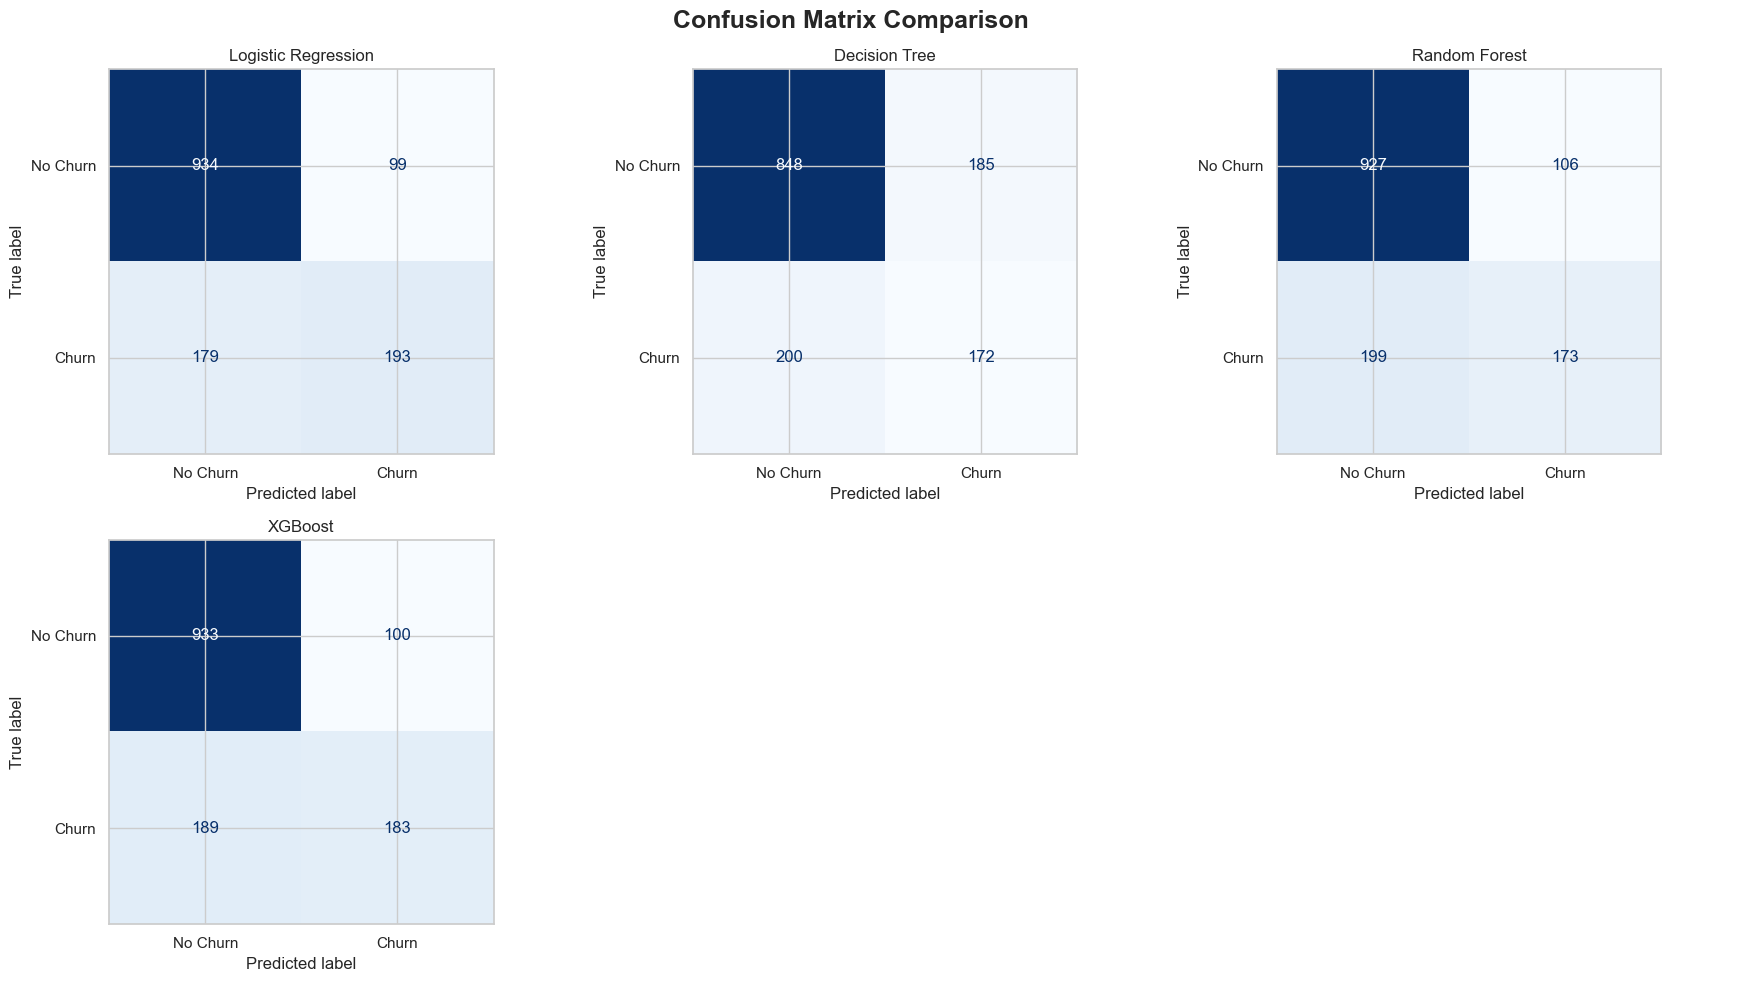

In [13]:
# ==========================================================
# Confusion Matrix Comparison
# ==========================================================
print_section("CONFUSION MATRIX COMPARISON")

n_models = len(trained_models)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, (model_name, model) in enumerate(trained_models.items()):

    cm = confusion_matrix(y_test, predictions[model_name])

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["No Churn", "Churn"]
    )

    disp.plot(
        ax=axes[idx],
        cmap="Blues",
        colorbar=False
    )

    axes[idx].set_title(model_name)

# Hide unused subplot
for j in range(idx + 1, len(axes)):
    axes[j].axis("off")

plt.suptitle(
    "Confusion Matrix Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

In [14]:
# ==========================================================
# Classification Reports
# ==========================================================
print_section("CLASSIFICATION REPORTS")

classification_reports = {}

for model_name in trained_models.keys():

    report = classification_report(
        y_test,
        predictions[model_name],
        output_dict=True
    )

    classification_reports[model_name] = pd.DataFrame(report).transpose()

    print(f"\n{'='*70}")
    print(model_name)
    print('='*70)

    display(
        classification_reports[model_name].style.format("{:.4f}")
    )

CLASSIFICATION REPORTS

Logistic Regression


,precision,recall,f1-score,support
0,0.8392,0.9042,0.8705,1033.0000
1,0.6610,0.5188,0.5813,372.0000
accuracy,0.8021,0.8021,0.8021,0.8021
macro avg,0.7501,0.7115,0.7259,1405.0000
weighted avg,0.7920,0.8021,0.7939,1405.0000



Decision Tree


,precision,recall,f1-score,support
0,0.8092,0.8209,0.8150,1033.0000
1,0.4818,0.4624,0.4719,372.0000
accuracy,0.7260,0.7260,0.7260,0.7260
macro avg,0.6455,0.6416,0.6434,1405.0000
weighted avg,0.7225,0.7260,0.7241,1405.0000



Random Forest


,precision,recall,f1-score,support
0,0.8233,0.8974,0.8587,1033.0000
1,0.6201,0.4651,0.5315,372.0000
accuracy,0.7829,0.7829,0.7829,0.7829
macro avg,0.7217,0.6812,0.6951,1405.0000
weighted avg,0.7695,0.7829,0.7721,1405.0000



XGBoost


,precision,recall,f1-score,support
0,0.8316,0.9032,0.8659,1033.0000
1,0.6466,0.4919,0.5588,372.0000
accuracy,0.7943,0.7943,0.7943,0.7943
macro avg,0.7391,0.6976,0.7123,1405.0000
weighted avg,0.7826,0.7943,0.7846,1405.0000


ROC CURVE COMPARISON


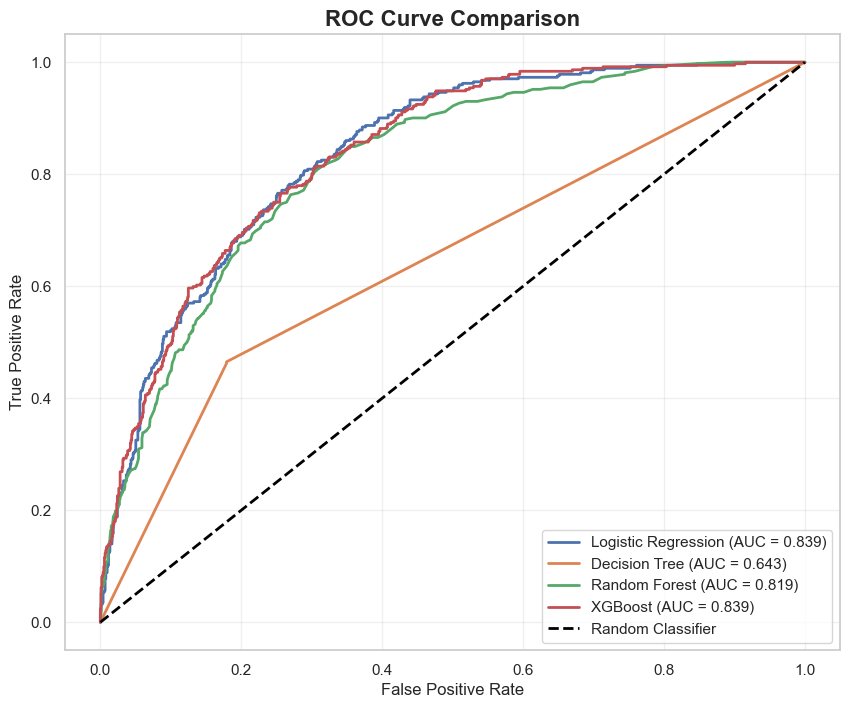

In [15]:
# ==========================================================
# ROC Curve Comparison
# ==========================================================
print_section("ROC CURVE COMPARISON")

plt.figure(figsize=(10,8))

for model_name in trained_models.keys():

    fpr, tpr, _ = roc_curve(
        y_test,
        probabilities[model_name]
    )

    auc_score = roc_auc_score(
        y_test,
        probabilities[model_name]
    )

    plt.plot(
        fpr,
        tpr,
        linewidth=2,
        label=f"{model_name} (AUC = {auc_score:.3f})"
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=2,
    color="black",
    label="Random Classifier"
)

plt.title(
    "ROC Curve Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

PRECISION-RECALL CURVE COMPARISON


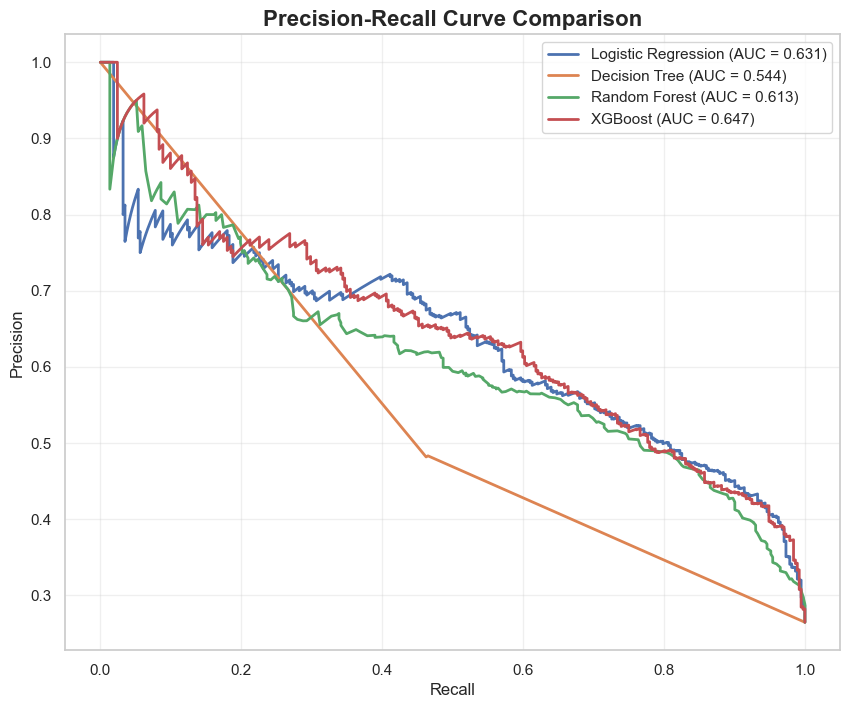

In [16]:
# ==========================================================
# Precision-Recall Curve Comparison
# ==========================================================
print_section("PRECISION-RECALL CURVE COMPARISON")

plt.figure(figsize=(10,8))

for model_name in trained_models.keys():

    precision, recall, _ = precision_recall_curve(
        y_test,
        probabilities[model_name]
    )

    pr_auc = auc(recall, precision)

    plt.plot(
        recall,
        precision,
        linewidth=2,
        label=f"{model_name} (AUC = {pr_auc:.3f})"
    )

plt.title(
    "Precision-Recall Curve Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

In [17]:
# ==========================================================
# Threshold Optimization Analysis
# ==========================================================
print_section("THRESHOLD OPTIMIZATION ANALYSIS")

best_model_name = best_model["Model"]
best_model = trained_models[best_model_name]

thresholds = np.arange(0.10, 0.95, 0.05)

threshold_results = []

y_prob = probabilities[best_model_name]

for threshold in thresholds:

    y_pred = (y_prob >= threshold).astype(int)

    threshold_results.append({
        "Threshold": threshold,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred)
    })

threshold_df = pd.DataFrame(threshold_results)

display(
    threshold_df.style.format({
        "Threshold": "{:.2f}",
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}"
    })
)

THRESHOLD OPTIMIZATION ANALYSIS


,Threshold,Accuracy,Precision,Recall,F1 Score
0,0.10,0.6142,0.4036,0.9570,0.5678
1,0.15,0.6633,0.4353,0.9140,0.5898
2,0.20,0.7096,0.4729,0.8441,0.6062
3,0.25,0.7367,0.5017,0.7903,0.6138
4,0.30,0.7573,0.5299,0.7392,0.6173
5,0.35,0.7694,0.5515,0.6909,0.6134
6,0.40,0.7779,0.5728,0.6344,0.6020
7,0.45,0.7929,0.6181,0.5699,0.5930
8,0.50,0.8021,0.6610,0.5188,0.5813
9,0.55,0.8007,0.6825,0.4624,0.5513


THRESHOLD PERFORMANCE VISUALIZATION


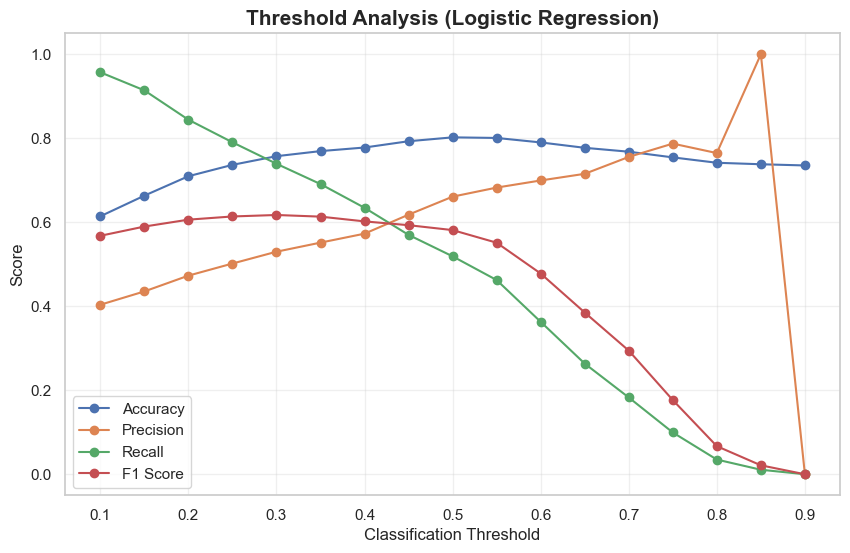

In [18]:
# ==========================================================
# Threshold Performance Curves
# ==========================================================
print_section("THRESHOLD PERFORMANCE VISUALIZATION")

plt.figure(figsize=(10,6))

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    threshold_df["Threshold"],
    threshold_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.title(
    f"Threshold Analysis ({best_model_name})",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Classification Threshold")
plt.ylabel("Score")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

MODEL CALIBRATION


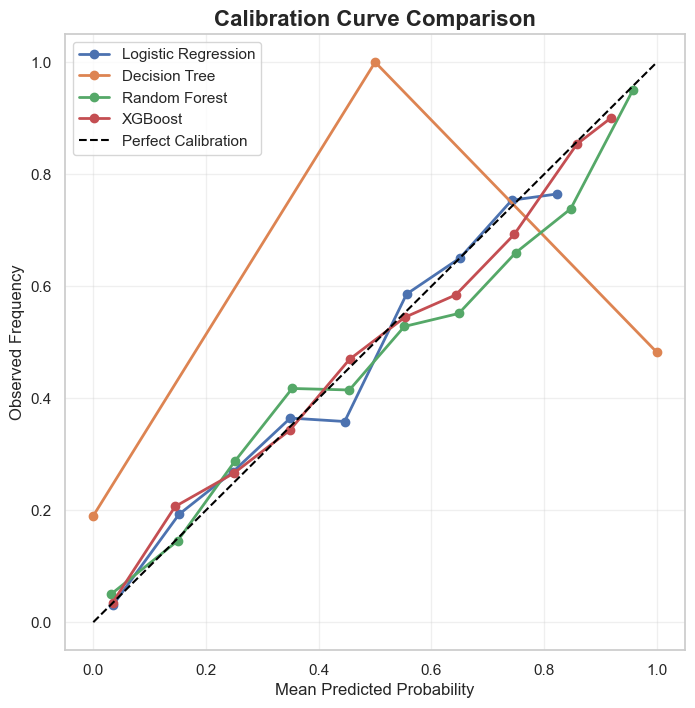

In [19]:
# ==========================================================
# Calibration Curve Comparison
# ==========================================================
print_section("MODEL CALIBRATION")

plt.figure(figsize=(8,8))

for model_name in trained_models.keys():

    prob_true, prob_pred = calibration_curve(
        y_test,
        probabilities[model_name],
        n_bins=10
    )

    plt.plot(
        prob_pred,
        prob_true,
        marker="o",
        linewidth=2,
        label=model_name
    )

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="black",
    label="Perfect Calibration"
)

plt.title(
    "Calibration Curve Comparison",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Mean Predicted Probability")
plt.ylabel("Observed Frequency")

plt.legend()

plt.grid(alpha=0.3)

plt.show()

PREDICTED PROBABILITY DISTRIBUTION


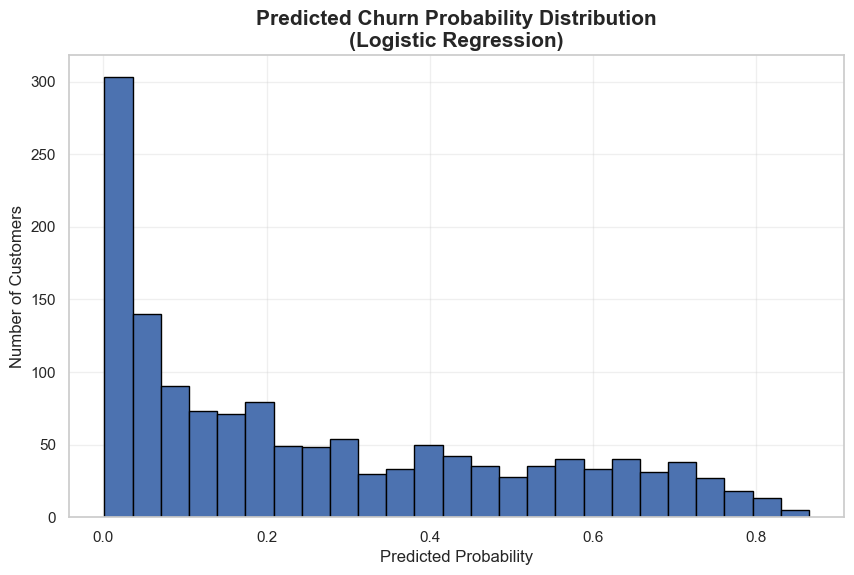

In [20]:
# ==========================================================
# Predicted Probability Distribution
# ==========================================================
print_section("PREDICTED PROBABILITY DISTRIBUTION")

plt.figure(figsize=(10,6))

plt.hist(
    probabilities[best_model_name],
    bins=25,
    edgecolor="black"
)

plt.title(
    f"Predicted Churn Probability Distribution\n({best_model_name})",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel("Predicted Probability")

plt.ylabel("Number of Customers")

plt.grid(alpha=0.3)

plt.show()

In [21]:
# ==========================================================
# Business Cost Analysis
# ==========================================================
print_section("BUSINESS COST ANALYSIS")

business_cost = []

for model_name in trained_models.keys():

    cm = confusion_matrix(
        y_test,
        predictions[model_name]
    )

    tn, fp, fn, tp = cm.ravel()

    business_cost.append({

        "Model": model_name,

        "True Positives": tp,

        "True Negatives": tn,

        "False Positives": fp,

        "False Negatives": fn

    })

business_cost_df = pd.DataFrame(business_cost)

display(business_cost_df)

BUSINESS COST ANALYSIS


,Model,True Positives,True Negatives,False Positives,False Negatives
0,Logistic Regression,193,934,99,179
1,Decision Tree,172,848,185,200
2,Random Forest,173,927,106,199
3,XGBoost,183,933,100,189


In [22]:
# ==========================================================
# Business Interpretation
# ==========================================================
print_section("BUSINESS INTERPRETATION")

for _, row in business_cost_df.iterrows():

    print(f"\n{row['Model']}")

    print(f"False Positives : {row['False Positives']}")
    print("→ Retention offer sent to a customer who would not churn.")

    print(f"False Negatives : {row['False Negatives']}")
    print("→ Actual churn customer missed by the model.")

BUSINESS INTERPRETATION

Logistic Regression
False Positives : 99
→ Retention offer sent to a customer who would not churn.
False Negatives : 179
→ Actual churn customer missed by the model.

Decision Tree
False Positives : 185
→ Retention offer sent to a customer who would not churn.
False Negatives : 200
→ Actual churn customer missed by the model.

Random Forest
False Positives : 106
→ Retention offer sent to a customer who would not churn.
False Negatives : 199
→ Actual churn customer missed by the model.

XGBoost
False Positives : 100
→ Retention offer sent to a customer who would not churn.
False Negatives : 189
→ Actual churn customer missed by the model.


In [23]:
# ==========================================================
# Weighted Model Ranking
# ==========================================================
print_section("MODEL RANKING")

ranking_df = evaluation_df.copy()

ranking_df["Overall Score"] = (

      ranking_df["ROC AUC"] * 0.35

    + ranking_df["F1 Score"] * 0.30

    + ranking_df["Recall"] * 0.20

    + ranking_df["Accuracy"] * 0.15

)

ranking_df = (

    ranking_df

    .sort_values(

        by="Overall Score",

        ascending=False

    )

    .reset_index(drop=True)

)

ranking_df.index += 1

display(

    ranking_df.style.format({

        "Accuracy":"{:.4f}",

        "Precision":"{:.4f}",

        "Recall":"{:.4f}",

        "F1 Score":"{:.4f}",

        "ROC AUC":"{:.4f}",

        "Overall Score":"{:.4f}"

    })

)

MODEL RANKING


,Model,Accuracy,Balanced Accuracy,Precision,Recall,F1 Score,ROC AUC,Log Loss,Brier Score,MCC,Cohen Kappa,Overall Score
1,Logistic Regression,0.8021,0.711490,0.6610,0.5188,0.5813,0.8391,0.421915,0.138657,0.459941,0.454233,0.6922
2,XGBoost,0.7943,0.697565,0.6466,0.4919,0.5588,0.8386,0.422028,0.138671,0.434682,0.427882,0.6787
3,Random Forest,0.7829,0.681220,0.6201,0.4651,0.5315,0.8190,0.447369,0.146280,0.400854,0.393950,0.6565
4,Decision Tree,0.7260,0.641638,0.4818,0.4624,0.4719,0.6427,9.851570,0.273488,0.287089,0.286978,0.5679


In [24]:
# ==========================================================
# Production Recommendation
# ==========================================================
print_section("PRODUCTION RECOMMENDATION")

recommended_model = ranking_df.iloc[0]

print(f"🏆 Recommended Model : {recommended_model['Model']}")

print(f"\nOverall Score : {recommended_model['Overall Score']:.4f}")

print(f"Accuracy      : {recommended_model['Accuracy']:.4f}")

print(f"Precision     : {recommended_model['Precision']:.4f}")

print(f"Recall        : {recommended_model['Recall']:.4f}")

print(f"F1 Score      : {recommended_model['F1 Score']:.4f}")

print(f"ROC AUC       : {recommended_model['ROC AUC']:.4f}")

print("\nRecommendation")

print("- Provides the strongest balance between discrimination,")
print("  classification performance, and business usefulness.")

print("- Selected as the production model for downstream")
print("  explainability, deployment, and business insights.")

PRODUCTION RECOMMENDATION
🏆 Recommended Model : Logistic Regression

Overall Score : 0.6922
Accuracy      : 0.8021
Precision     : 0.6610
Recall        : 0.5188
F1 Score      : 0.5813
ROC AUC       : 0.8391

Recommendation
- Provides the strongest balance between discrimination,
  classification performance, and business usefulness.
- Selected as the production model for downstream
  explainability, deployment, and business insights.
